# A Simple VAE Tutorial for Fake scRNA-seq Data

This notebook is a classroom walkthrough of a variational autoencoder on **synthetic single-cell RNA-seq data**. The goal is to keep the notebook as simple and visual as possible while still matching the main workflow you will use later on the Zeisel project.

We will do only six things:

1. simulate fake counts;
2. normalize with `log1p(CPM)`;
3. keep the most variable genes;
4. build a PCA baseline;
5. fit a 2D VAE;
6. compare the two latent spaces.

The hidden labels are used **only for evaluation and plotting**, not for fitting.

In [1]:
import os
import random

os.environ.setdefault("MPLCONFIGDIR", ".matplotlib-cache")
os.environ.setdefault("XDG_CACHE_HOME", ".cache")
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

SEED = 469
CELL_TYPES = ["astro_like", "endo_like", "microglia_like", "pyramidal_like"]

sns.set_theme(style="whitegrid", context="notebook")

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()

## 1. Simulate fake scRNA-seq counts

We want a small dataset that behaves like single-cell data:

- many genes;
- sparse counts;
- unequal library sizes;
- a few hidden cell types.

The biology is fake, but the **data shape and preprocessing** are realistic enough for teaching.

In [2]:
def simulate_scrna_like_counts(n_types=4, cells_per_type=80, n_genes=120, seed=SEED):
    rng = np.random.default_rng(seed)
    labels = []
    counts = []

    # Each fake cell type lives around a different point in a 2D hidden space.
    latent_centers = np.array(
        [
            [-2.2, -1.8],
            [-2.0,  2.0],
            [ 2.0, -1.5],
            [ 2.2,  2.0],
        ]
    )

    base_log_rate = rng.normal(-3.6, 0.25, size=n_genes)
    nonlinear_weights = rng.normal(0, 0.22, size=(5, n_genes))
    marker_blocks = np.array_split(np.arange(n_genes), n_types)

    for cell_type_idx, center in enumerate(latent_centers):
        marker_effect = np.zeros(n_genes)
        block = marker_blocks[cell_type_idx]
        marker_effect[block] += rng.normal(1.0, 0.12, size=len(block))

        extra_idx = rng.choice(
            np.setdiff1d(np.arange(n_genes), block),
            size=8,
            replace=False,
        )
        marker_effect[extra_idx] += rng.normal(0.4, 0.08, size=8)

        for _ in range(cells_per_type):
            z = center + rng.normal(0, 0.45, size=2)
            features = np.array([z[0], z[1], z[0] * z[1], z[0] ** 2, z[1] ** 2])
            log_mu = (
                base_log_rate
                + features @ nonlinear_weights
                + marker_effect
                + rng.normal(0, 0.09, size=n_genes)
            )

            mu = np.exp(log_mu)
            library_size = int(rng.lognormal(mean=8.2, sigma=0.28))
            prob = mu / mu.sum()
            cell_counts = rng.poisson(library_size * prob).astype(np.int32)

            dropout_prob = 0.25 * np.exp(-0.8 * np.log1p(cell_counts + 1))
            dropout_mask = rng.random(n_genes) < dropout_prob
            cell_counts[dropout_mask] = 0

            counts.append(cell_counts)
            labels.append(CELL_TYPES[cell_type_idx])

    counts = np.vstack(counts)
    labels = np.array(labels)
    gene_names = [f"gene_{i:03d}" for i in range(n_genes)]

    return counts, labels, gene_names, marker_blocks


counts, hidden_labels, gene_names, marker_blocks = simulate_scrna_like_counts()

print("counts shape:", counts.shape)
print("unique cell types:", pd.unique(hidden_labels).tolist())
print("fraction of zeros:", round((counts == 0).mean(), 3))

pd.DataFrame(
    counts[:5, :8],
    index=[f"cell_{i}" for i in range(5)],
    columns=gene_names[:8],
)

counts shape: (320, 120)
unique cell types: ['astro_like', 'endo_like', 'microglia_like', 'pyramidal_like']
fraction of zeros: 0.184


,gene_000,gene_001,gene_002,gene_003,gene_004,gene_005,gene_006,gene_007
cell_0,6,11,29,139,29,184,3,8
cell_1,5,16,17,101,20,121,12,5
cell_2,11,12,7,70,14,219,7,21
cell_3,1,0,0,5,0,242,0,11
cell_4,9,5,4,28,21,298,6,18


## 2. Normalize the counts with `log1p(CPM)`

This is the same idea you could later use on the real Zeisel data:

- divide by each cell's library size;
- multiply by 10,000;
- apply `log1p`.

,quantity,value
0,cells,320
1,genes,120
2,median library size,3574
3,median zero fraction,14.2%


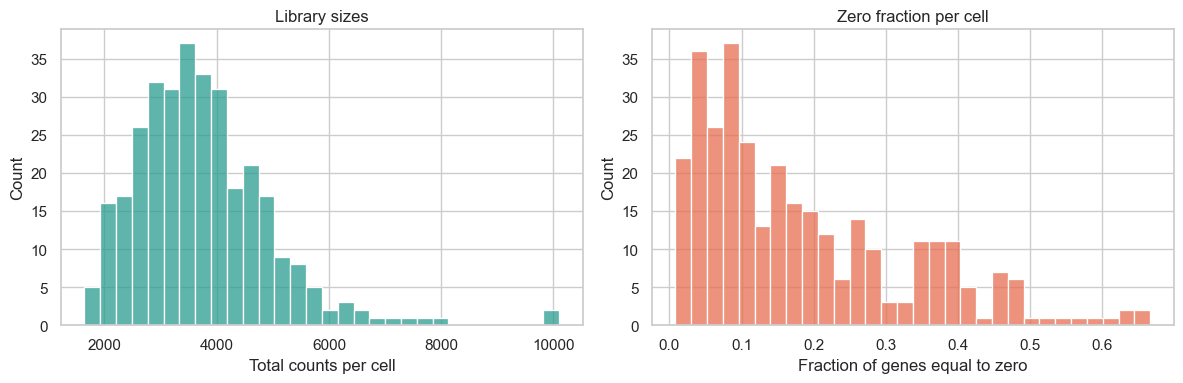

In [3]:
library_size = counts.sum(axis=1, keepdims=True)
cpm = counts / np.clip(library_size, 1, None) * 1.0e4
log_cpm = np.log1p(cpm).astype(np.float32)

summary = pd.DataFrame(
    {
        "quantity": [
            "cells",
            "genes",
            "median library size",
            "median zero fraction",
        ],
        "value": [
            counts.shape[0],
            counts.shape[1],
            int(np.median(library_size)),
            f"{np.median((counts == 0).mean(axis=1)):.1%}",
        ],
    }
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(library_size.ravel(), bins=30, ax=axes[0], color="#2A9D8F")
axes[0].set_title("Library sizes")
axes[0].set_xlabel("Total counts per cell")

sns.histplot((counts == 0).mean(axis=1), bins=30, ax=axes[1], color="#E76F51")
axes[1].set_title("Zero fraction per cell")
axes[1].set_xlabel("Fraction of genes equal to zero")

plt.tight_layout()
plt.show()

## 3. Keep the most variable genes

This is also close to what you will do in the project. We keep the top variable genes and standardize them before giving them to PCA or the VAE.

In [4]:
def top_variable_genes(log_cpm, top_n):
    return np.argsort(log_cpm.var(axis=0))[-top_n:]


top_idx = top_variable_genes(log_cpm, top_n=80)
scaler = StandardScaler()
x = scaler.fit_transform(log_cpm[:, top_idx]).astype(np.float32)

print("input to PCA/VAE:", x.shape)
print("first 10 selected genes:", [gene_names[i] for i in top_idx[:10]])

input to PCA/VAE: (320, 80)
first 10 selected genes: ['gene_111', 'gene_079', 'gene_080', 'gene_023', 'gene_052', 'gene_039', 'gene_051', 'gene_082', 'gene_093', 'gene_112']


## 4. Classical baseline: PCA + K-means

We will use a very simple classical baseline:

- run PCA;
- cluster the PCA coordinates with K-means.

We cluster on `PCA(5)` but plot `PCA(2)`, because 2D is easier to see in class.

PCA + KMeans: ARI = 0.667, NMI = 0.728


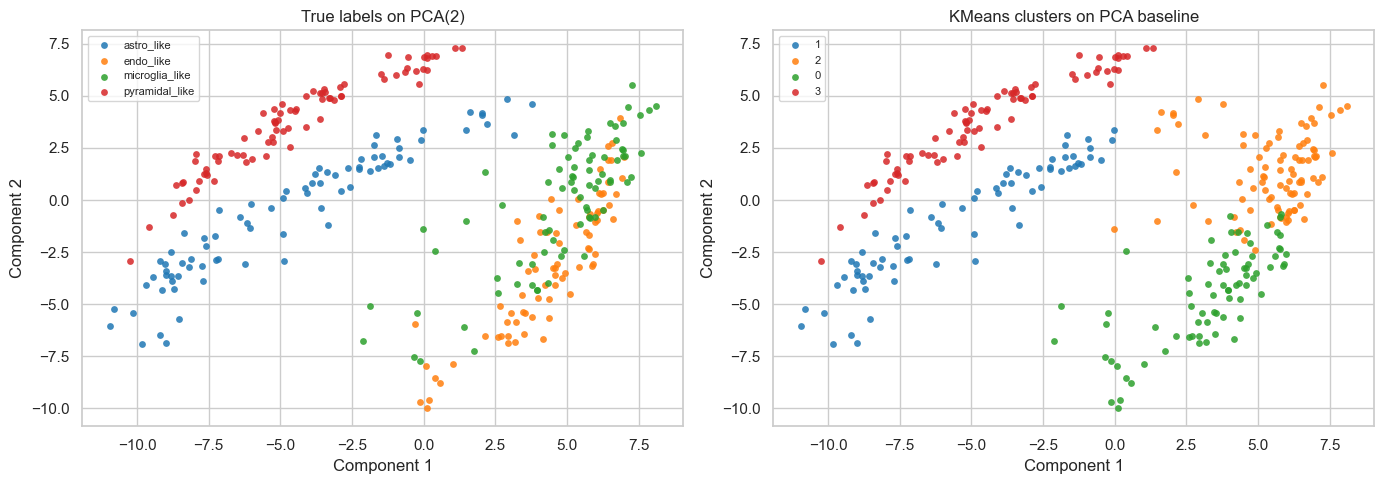

In [5]:
def plot_embedding(ax, coords, labels, title):
    labels = np.asarray(labels)
    order = pd.unique(labels)
    palette = sns.color_palette("tab10", n_colors=len(order))
    for label, color in zip(order, palette):
        mask = labels == label
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            s=24,
            alpha=0.85,
            color=[color],
            label=str(label),
            linewidths=0,
        )
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(loc="best", fontsize=8, frameon=True)


pca2 = PCA(n_components=2, random_state=SEED).fit_transform(x)
pca5 = PCA(n_components=5, random_state=SEED).fit_transform(x)
pca_kmeans = KMeans(n_clusters=4, n_init=50, random_state=SEED).fit_predict(pca5)

pca_ari = adjusted_rand_score(hidden_labels, pca_kmeans)
pca_nmi = normalized_mutual_info_score(hidden_labels, pca_kmeans)

print(f"PCA + KMeans: ARI = {pca_ari:.3f}, NMI = {pca_nmi:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_embedding(axes[0], pca2, hidden_labels, "True labels on PCA(2)")
plot_embedding(axes[1], pca2, pca_kmeans, "KMeans clusters on PCA baseline")
plt.tight_layout()
plt.show()

## 5. Define the VAE

This is the core model. It has:

- one hidden layer in the encoder;
- two heads, `mu` and `logvar`;
- one hidden layer in the decoder.

The key VAE line is:

`z = mu + epsilon * exp(0.5 * logvar)`

That is the reparameterization trick.

In [11]:
# Define the VAE class, inheriting from PyTorch's base Module class
class VariationalAutoencoder(nn.Module):
    # Constructor: input_dim = size of input data, hidden_dim = neurons in hidden layer, latent_dim = size of latent space
    def __init__(self, input_dim, hidden_dim=64, latent_dim=2):
        # Initialize the parent nn.Module class
        super().__init__()
        # Build the encoder network: compresses input down to hidden_dim size
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),  # Fully connected layer: input_dim → hidden_dim
            nn.ReLU(),                          # Non-linear activation to learn complex patterns
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)      # Linear layer to output the mean (μ) of the latent distribution
        self.logvar = nn.Linear(hidden_dim, latent_dim)  # Linear layer to output the log-variance (log σ²) of the latent distribution
        # Build the decoder network: reconstructs data from the latent space back to original size
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),  # Fully connected layer: latent_dim → hidden_dim
            nn.ReLU(),                           # Non-linear activation
            nn.Linear(hidden_dim, input_dim),    # Fully connected layer: hidden_dim → input_dim (reconstructed output)
        )

    def encode(self, x):
        h = self.encoder(x)        # Pass input through encoder to get hidden representation
        return self.mu(h), self.logvar(h)  # Return both the mean and log-variance for the latent distribution

    def forward(self, x):
        mu, logvar = self.encode(x)  # Encode input into latent distribution parameters (μ and log σ²)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)  # Reparameterization trick: sample z = μ + ε·σ, where ε ~ N(0,1) and σ = exp(0.5 * log σ²)
        recon = self.decoder(z)      # Decode the sampled latent vector z back to the original input space
        return recon, mu, logvar     # Return reconstruction, mean, and log-variance (mu/logvar needed to compute KL loss during training)

## 6. Train the VAE

We use the standard VAE loss:

- reconstruction loss: match the input;
- KL loss: keep the latent space close to a standard normal;
- total loss: `reconstruction + beta * KL`.

We choose `latent_dim = 2` so the learned space is easy to plot.

In [12]:
# Define the VAE training function with configurable architecture and training hyperparameters
def train_vae(x, hidden_dim=64, latent_dim=2, beta=0.01, epochs=80, batch_size=64):
    set_seed()                                                        # Fix random seeds for reproducibility across runs
    x_tensor = torch.tensor(x, dtype=torch.float32)                  # Convert numpy array to a float32 PyTorch tensor
    loader = DataLoader(TensorDataset(x_tensor), batch_size=batch_size, shuffle=True)  # Wrap data in a DataLoader for mini-batch iteration with shuffling each epoch

    model = VariationalAutoencoder(
        input_dim=x_tensor.shape[1],   # Set input size to number of features in the dataset
        hidden_dim=hidden_dim,          # Pass hidden layer size to the model
        latent_dim=latent_dim,          # Pass latent space dimensions to the model
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Use Adam optimizer with learning rate 0.001 to update model weights
    history = []                                                # Initialize empty list to track per-epoch metrics

    for epoch in range(1, epochs + 1):  # Loop over each training epoch (1-indexed)
        losses = []        # Reset batch loss accumulator at the start of each epoch
        recon_losses = []  # Reset reconstruction loss accumulator
        kl_losses = []     # Reset KL divergence loss accumulator

        for (batch,) in loader:                              # Iterate over mini-batches from the DataLoader
            optimizer.zero_grad()                            # Clear gradients from the previous step to prevent accumulation
            recon, mu, logvar = model(batch)                 # Forward pass: get reconstruction, latent mean, and log-variance
            recon_loss = F.mse_loss(recon, batch)            # Compute reconstruction loss: MSE between input and its reconstruction
            kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())  # KL divergence: measures how far the latent distribution is from standard normal N(0,1)
            loss = recon_loss + beta * kl_loss               # Total loss: reconstruction + β-weighted KL (β controls the tradeoff)
            loss.backward()                                  # Backpropagate gradients through the entire model
            optimizer.step()                                 # Update model weights using the computed gradients

            losses.append(loss.item())             # Record scalar total loss for this batch
            recon_losses.append(recon_loss.item()) # Record scalar reconstruction loss for this batch
            kl_losses.append(kl_loss.item())       # Record scalar KL loss for this batch

        history.append(
            {
                "epoch": epoch,                          # Store epoch number
                "loss": float(np.mean(losses)),          # Average total loss across all batches this epoch
                "recon_loss": float(np.mean(recon_losses)),  # Average reconstruction loss this epoch
                "kl_loss": float(np.mean(kl_losses)),    # Average KL loss this epoch
            }
        )

    with torch.no_grad():                              # Disable gradient tracking (inference only, saves memory)
        latent_mean, _ = model.encode(x_tensor)        # Encode full dataset to get latent means μ (discard log-variance)

    return model, latent_mean.numpy(), pd.DataFrame(history)  # Return trained model, numpy latent means, and history as a DataFrame


# Train the VAE on x with specified hyperparameters and unpack the three return values
vae, latent_mean, history = train_vae(x, hidden_dim=64, latent_dim=2, beta=0.01, epochs=80)
# Cluster the 2D latent means into 4 clusters using KMeans with 50 random initialisations for stability
vae_kmeans = KMeans(n_clusters=4, n_init=50, random_state=SEED).fit_predict(latent_mean)

vae_ari = adjusted_rand_score(hidden_labels, vae_kmeans)          # Compute ARI: measures cluster-to-true-label agreement (1.0 = perfect)
vae_nmi = normalized_mutual_info_score(hidden_labels, vae_kmeans) # Compute NMI: measures shared information between clusters and true labels (1.0 = perfect)

print(f"VAE + KMeans: ARI = {vae_ari:.3f}, NMI = {vae_nmi:.3f}") # Print both metrics rounded to 3 decimal places
history.tail()  # Display the last 5 rows of training history to inspect convergence

VAE + KMeans: ARI = 0.775, NMI = 0.815


,epoch,loss,recon_loss,kl_loss
75,76,0.341678,0.307660,3.401852
76,77,0.339706,0.306229,3.347659
77,78,0.338980,0.304934,3.404548
78,79,0.337036,0.303290,3.374546
79,80,0.336420,0.302379,3.404038


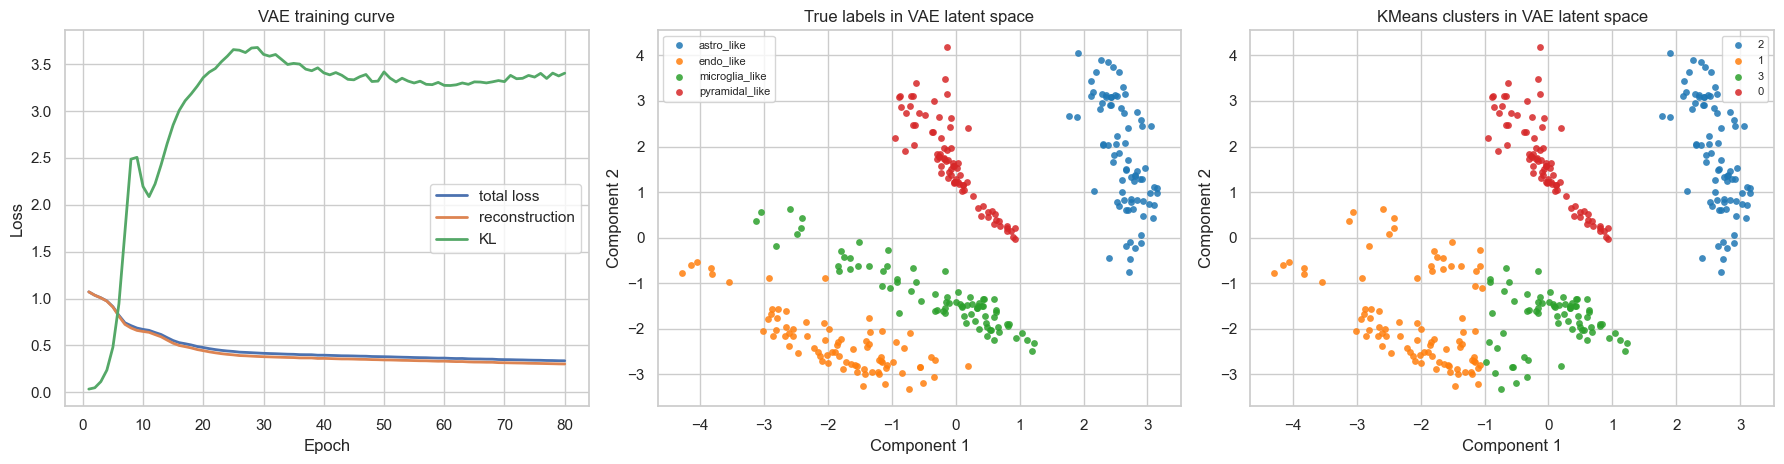

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(history["epoch"], history["loss"], label="total loss", lw=2)
axes[0].plot(history["epoch"], history["recon_loss"], label="reconstruction", lw=2)
axes[0].plot(history["epoch"], history["kl_loss"], label="KL", lw=2)
axes[0].set_title("VAE training curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

plot_embedding(axes[1], latent_mean, hidden_labels, "True labels in VAE latent space")
plot_embedding(axes[2], latent_mean, vae_kmeans, "KMeans clusters in VAE latent space")

plt.tight_layout()
plt.show()

## 7. Compare PCA and the VAE

On this fake dataset, the VAE often learns a slightly cleaner 2D representation than the classical PCA baseline.

That is the main lesson:

- PCA is a perfectly reasonable baseline;
- a VAE is a learned nonlinear alternative;
- later, on Zeisel, you can compare both.

In [14]:
comparison = pd.DataFrame(
    [
        {
            "representation": "PCA(5) + KMeans",
            "ARI": pca_ari,
            "NMI": pca_nmi,
        },
        {
            "representation": "2D VAE latent mean + KMeans",
            "ARI": vae_ari,
            "NMI": vae_nmi,
        },
    ]
).round(3)

comparison

,representation,ARI,NMI
0,PCA(5) + KMeans,0.667,0.728
1,2D VAE latent mean + KMeans,0.775,0.815


## 8. What did the decoder learn?

For scRNA data, we can do:

- move across a grid in the 2D latent space;
- decode each point into a gene-expression profile;
- average over the marker genes for each fake cell type.

Each heatmap below shows where one marker program is strongest in latent space.

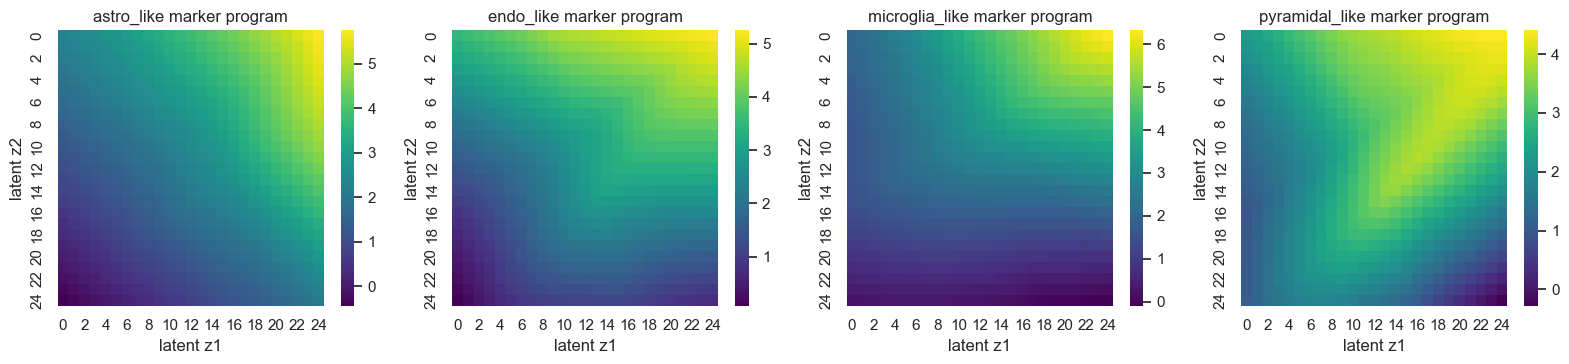

In [15]:
def plot_marker_landscapes(model, scaler, selected_gene_idx, marker_blocks, names):
    with torch.no_grad():
        z = latent_mean
        grid_x = np.linspace(z[:, 0].min() - 0.5, z[:, 0].max() + 0.5, 25)
        grid_y = np.linspace(z[:, 1].min() - 0.5, z[:, 1].max() + 0.5, 25)
        xx, yy = np.meshgrid(grid_x, grid_y)
        latent_grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

        decoded_std = model.decoder(torch.tensor(latent_grid)).numpy()
        decoded_log_cpm = scaler.inverse_transform(decoded_std)

    fig, axes = plt.subplots(1, len(names), figsize=(4 * len(names), 3.8))
    for ax, name, block in zip(axes, names, marker_blocks):
        mask = np.isin(selected_gene_idx, block)
        score = decoded_log_cpm[:, mask].mean(axis=1).reshape(xx.shape)
        sns.heatmap(score, cmap="viridis", ax=ax, cbar=True)
        ax.set_title(f"{name} marker program")
        ax.set_xlabel("latent z1")
        ax.set_ylabel("latent z2")

    plt.tight_layout()
    plt.show()


plot_marker_landscapes(
    model=vae,
    scaler=scaler,
    selected_gene_idx=top_idx,
    marker_blocks=marker_blocks,
    names=CELL_TYPES,
)

## How to adapt this notebook to Zeisel

The move from fake data to the project is straightforward:

1. replace the simulation cell with code that loads `Zeisel.csv`;
2. compute `log1p(CPM)` the same way;
3. keep the same VAE class and training loop;
4. choose a larger latent dimension if you want;
5. use the real labels only at the end for evaluation.